# Credit Risk: PD Model, Score Scaling & Expected Loss Backtest

**Data:** Lending Club accepted loans (2007 to 2019 Q3), Kaggle `denychaen/lending-club-loans-rejects-data`
**Objective:** Build a Probability of Default (PD) model with **out-of-time validation**, rescale scores with PDO, and estimate Expected Loss (EL = PD x LGD x EAD) **backtested against realized losses**.

**Design choices (and why)**
- **Out-of-time split by issue date**, not a random split. Models are used on future loans, so they must be tested on future loans.
- **36-month loans only (default, configurable).** The data ends in 2019 Q3. A 60-month loan issued after 2014 has not reached maturity, so among those loans only the early outcomes are observed, which biases default rates. Every 36-month loan issued before mid-2016 has resolved.
- **Imputation, scaling and LGD are fitted on training data only**, to avoid leakage.
- EL is evaluated on **held-out loans** and compared with what was actually lost.

**Requirements:** `pandas numpy scipy scikit-learn xgboost matplotlib
 kagglehub`

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 140)

# ------------------------- Configuration -------------------------
RANDOM_STATE = 42
LOCAL_CSV = None          # e.g. r"C:\data\appl_accepted_20072019Q3.csv". None = download with kagglehub
ONLY_36M = True           # see design notes above
TRAIN_END = "2014-12-31"  # train on loans issued up to this date
TEST_START = "2015-01-01" # test on later vintages
TEST_END = "2016-06-30"
INCLUDE_INT_RATE = True   # int_rate is set by Lending Club's own risk view; sensitivity shown in section 3
PDO, BASE_SCORE = 20, 600 # score scaling: 20 points double the odds, 600 = average-risk borrower

## 1. Data loading & target

In [3]:
USE_COLS = ["loan_amnt", "funded_amnt", "term", "int_rate", "emp_length", "home_ownership",
            "annual_inc", "verification_status", "issue_d", "loan_status", "purpose", "dti",
            "delinq_2yrs", "fico_range_low", "fico_range_high", "inq_last_6mths", "open_acc",
            "pub_rec", "revol_bal", "revol_util", "total_acc", "total_rec_prncp", "recoveries"]

def find_accepted_csv():
    if LOCAL_CSV:
        return LOCAL_CSV
    import kagglehub
    path = kagglehub.dataset_download("denychaen/lending-club-loans-rejects-data")
    fname = [f for f in sorted(os.listdir(path)) if "accepted" in f.lower()][0]
    return os.path.join(path, fname)

raw = pd.read_csv(find_accepted_csv(), usecols=USE_COLS, low_memory=False)
print("Raw shape:", raw.shape)
raw["loan_status"].value_counts(dropna=False)

Raw shape: (2650550, 23)


loan_status
Current                                                1217855
Fully Paid                                             1111884
Charged Off                                             273973
Late (31-120 days)                                       27067
In Grace Period                                          11386
Late (16-30 days)                                         5558
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     45
NaN                                                         33
Name: count, dtype: int64

In [4]:
# Keep only loans with a final outcome. 'Current' / 'Late' loans have no resolved outcome yet.
closed = raw[raw["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()
closed["target"] = (closed["loan_status"] == "Charged Off").astype(int)
print(f"Resolved loans: {len(closed):,} | default rate: {closed['target'].mean():.2%}")

Resolved loans: 1,385,857 | default rate: 19.77%


## 2. Feature engineering & vintage check


In [7]:
def pct_to_float(s):
    return pd.to_numeric(s.astype(str).str.rstrip("%"), errors="coerce")

# Parse issue dates: 'Dec-2015' first, then 'Dec-15', then a general fallback (e.g. '2015-12-01')
_s = closed["issue_d"].astype(str).str.strip()
issue_dt = pd.to_datetime(_s, format="%b-%Y", errors="coerce")
issue_dt = issue_dt.fillna(pd.to_datetime(_s, format="%b-%y", errors="coerce"))
_left = issue_dt.isna()
if _left.any():
    issue_dt.loc[_left] = pd.to_datetime(_s[_left], format="mixed", errors="coerce")
closed["issue_d_dt"] = issue_dt

bad_dates = closed["issue_d_dt"].isna().mean()
print(f"Unparsed issue dates: {bad_dates:.2%}")
if bad_dates > 0:
    print("Examples of unparsed values:")
    print(_s[closed["issue_d_dt"].isna()].value_counts().head(10))
assert bad_dates < 0.05, "More than 5% of issue dates unparsed. Check the examples above."

closed["term"] = closed["term"].astype(str).str.strip()
closed["int_rate_num"] = pct_to_float(closed["int_rate"])
closed["revol_util_num"] = pct_to_float(closed["revol_util"])

emp_map = {"< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4, "5 years": 5,
           "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9, "10+ years": 10}
closed["emp_length_num"] = closed["emp_length"].map(emp_map)
closed["fico_mid"] = (closed["fico_range_low"] + closed["fico_range_high"]) / 2.0   # low/high are near-identical

if ONLY_36M:
    closed = closed[closed["term"] == "36 months"]
print(f"Modelling population: {len(closed):,} loans")

Unparsed issue dates: 0.00%
Modelling population: 1,050,663 loans


In [9]:
# Vintage diagnostic: default rate by issue year and term.
# Unusual jumps in recent years for 60-month loans are the censoring problem that ONLY_36M avoids.
vint = (closed.assign(year=closed["issue_d_dt"].dt.year)
        .groupby(["year", "term"])["target"].agg(loans="count", default_rate="mean").reset_index())
print("Loans by issue year:")
print(vint.pivot(index="year", columns="term", values="loans").to_string(float_format=lambda x: f"{x:,.0f}"))
print("\nDefault rate by issue year:")
print(vint.pivot(index="year", columns="term", values="default_rate").to_string(float_format=lambda x: f"{x:.2%}"))

Loans by issue year:
term  36 months
year           
2007        251
2008       1562
2009       4716
2010       8466
2011      14101
2012      43470
2013     100422
2014     162570
2015     283026
2016     232353
2017     128538
2018      41268
2019      29920

Default rate by issue year:
term  36 months
year           
2007     17.93%
2008     15.81%
2009     12.60%
2010      9.95%
2011     10.63%
2012     13.58%
2013     12.33%
2014     13.73%
2015     14.89%
2016     19.85%
2017     20.01%
2018     13.24%
2019     11.92%


In [10]:
num_features = ["loan_amnt", "int_rate_num", "annual_inc", "dti", "fico_mid", "delinq_2yrs",
                "inq_last_6mths", "open_acc", "pub_rec", "revol_bal", "revol_util_num",
                "total_acc", "emp_length_num"]
if not INCLUDE_INT_RATE:
    num_features.remove("int_rate_num")
cat_features = ["home_ownership", "verification_status", "purpose"] + ([] if ONLY_36M else ["term"])

# Columns used only for splitting and loss calculation, never as model inputs
aux_cols = ["issue_d_dt", "target", "recoveries", "funded_amnt", "total_rec_prncp"]

data = closed.dropna(subset=["issue_d_dt"]).sort_values("issue_d_dt")
train_raw = data[data["issue_d_dt"] <= TRAIN_END]
test_raw = data[(data["issue_d_dt"] >= TEST_START) & (data["issue_d_dt"] <= TEST_END)]

# One-hot encode train+test together so the columns line up, then split again
combined = pd.concat([train_raw, test_raw])[num_features + cat_features + aux_cols]
combined = pd.get_dummies(combined, columns=cat_features, drop_first=True, dtype=int)
train = combined.iloc[:len(train_raw)].copy()
test = combined.iloc[len(train_raw):].copy()

# Impute with TRAIN medians only (no leakage from the test period)
medians = train[num_features].median()
print("Missing share before imputation (train):")
print(train[num_features].isna().mean().loc[lambda s: s > 0].round(4))
train[num_features] = train[num_features].fillna(medians)
test[num_features] = test[num_features].fillna(medians)

feature_cols = [c for c in train.columns if c not in aux_cols]
X_train, y_train = train[feature_cols], train["target"]
X_test, y_test = test[feature_cols], test["target"]

print(pd.DataFrame({
    "rows": [len(train), len(test)],
    "from": [train["issue_d_dt"].min().date(), test["issue_d_dt"].min().date()],
    "to": [train["issue_d_dt"].max().date(), test["issue_d_dt"].max().date()],
    "default_rate": [y_train.mean(), y_test.mean()]}, index=["train", "test"]))
print("Number of model features:", len(feature_cols))

Missing share before imputation (train):
revol_util_num   0.0007
emp_length_num   0.0512
dtype: float64
         rows        from          to  default_rate
train  335558  2007-06-01  2014-12-01        0.1306
test   423111  2015-01-01  2016-06-01        0.1603
Number of model features: 33


## 3. Baseline PD model: regularised logistic regression
Standardised inputs, so each odds ratio below is **per 1 standard deviation** increase. `int_rate` is set by Lending Club using its own risk assessment, so it overlaps with other risk drivers. The sensitivity run at the end of this section shows how much the model depends on it.

In [11]:
def ks_stat(y, p):
    y = np.asarray(y)
    return ks_2samp(p[y == 1], p[y == 0]).statistic

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logit = LogisticRegression(max_iter=1000, C=0.1)
logit.fit(X_train_s, y_train)
p_logit = logit.predict_proba(X_test_s)[:, 1]

auc_logit = roc_auc_score(y_test, p_logit)
print(f"Out-of-time Logistic AUC: {auc_logit:.4f} | Gini: {2*auc_logit-1:.4f} | KS: {ks_stat(y_test, p_logit):.4f}")

coef = pd.DataFrame({"Feature": feature_cols, "Coefficient": logit.coef_[0],
                     "Odds_Ratio": np.exp(logit.coef_[0])}).sort_values("Odds_Ratio", ascending=False)
print("\nHighest default-odds drivers:\n", coef.head(8).to_string(index=False))
print("\nMost protective drivers:\n", coef.tail(8).to_string(index=False))

Out-of-time Logistic AUC: 0.6908 | Gini: 0.3816 | KS: 0.2788

Highest default-odds drivers:
                             Feature  Coefficient  Odds_Ratio
                       int_rate_num       0.3349      1.3978
                                dti       0.1331      1.1424
                          loan_amnt       0.1023      1.1077
                     inq_last_6mths       0.0946      1.0992
                           open_acc       0.0758      1.0787
             purpose_small_business       0.0699      1.0724
                home_ownership_RENT       0.0503      1.0516
verification_status_Source Verified       0.0435      1.0444

Most protective drivers:
                 Feature  Coefficient  Odds_Ratio
         emp_length_num      -0.0093      0.9908
        purpose_wedding      -0.0162      0.9839
    purpose_credit_card      -0.0351      0.9655
home_ownership_MORTGAGE      -0.0514      0.9499
              revol_bal      -0.0566      0.9450
              total_acc      -0.0794 

In [12]:
# Sensitivity: how much of the model's power comes from int_rate?
if "int_rate_num" in feature_cols:
    cols_ni = [c for c in feature_cols if c != "int_rate_num"]
    sc = StandardScaler().fit(X_train[cols_ni])
    lg = LogisticRegression(max_iter=1000, C=0.1).fit(sc.transform(X_train[cols_ni]), y_train)
    auc_ni = roc_auc_score(y_test, lg.predict_proba(sc.transform(X_test[cols_ni]))[:, 1])
    print(f"Logistic AUC with int_rate:    {auc_logit:.4f}")
    print(f"Logistic AUC without int_rate: {auc_ni:.4f}")

Logistic AUC with int_rate:    0.6908
Logistic AUC without int_rate: 0.6595


## 4. Challenger model: XGBoost
The last 15% of the training period (by time) is held back as a validation set for early stopping. The test set is never used for tuning.

In [13]:
val_cut = int(len(train) * 0.85)
fit_part, val_part = train.iloc[:val_cut], train.iloc[val_cut:]

xgb = XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=4, min_child_weight=50,
                    subsample=0.8, colsample_bytree=0.8, eval_metric="auc",
                    early_stopping_rounds=30, tree_method="hist",
                    random_state=RANDOM_STATE, n_jobs=-1)
xgb.fit(fit_part[feature_cols], fit_part["target"],
        eval_set=[(val_part[feature_cols], val_part["target"])], verbose=False)

p_xgb = xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, p_xgb)
print(f"Best iteration: {getattr(xgb, 'best_iteration', 'n/a')}")
print(f"Out-of-time XGBoost AUC: {auc_xgb:.4f} | Gini: {2*auc_xgb-1:.4f} | KS: {ks_stat(y_test, p_xgb):.4f}")

Best iteration: 211
Out-of-time XGBoost AUC: 0.6939 | Gini: 0.3879 | KS: 0.2800


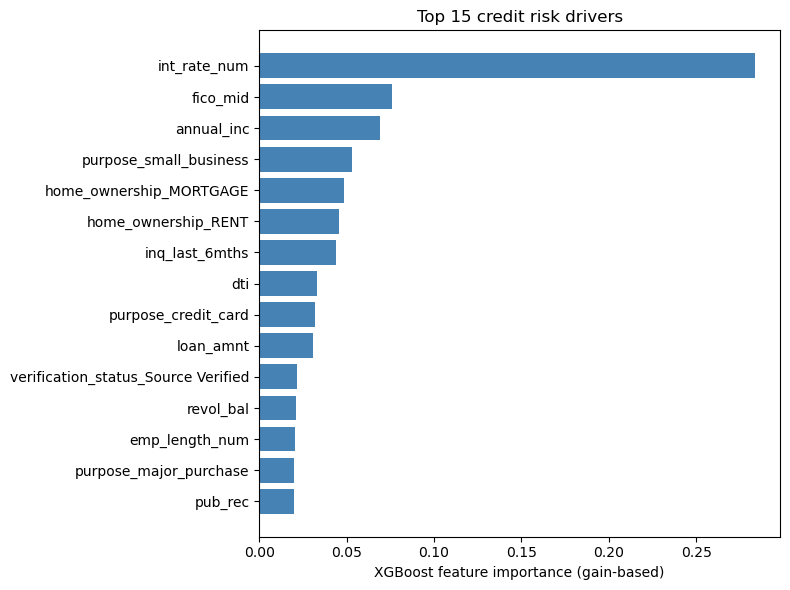

In [14]:
imp = (pd.DataFrame({"Feature": feature_cols, "Importance": xgb.feature_importances_})
       .sort_values("Importance").tail(15))
plt.figure(figsize=(8, 6))
plt.barh(imp["Feature"], imp["Importance"], color="steelblue")
plt.xlabel("XGBoost feature importance (gain-based)")
plt.title("Top 15 credit risk drivers")
plt.tight_layout()
plt.show()

## 5. Model validation (out-of-time)
Discrimination (AUC, Gini, KS), probability accuracy (Brier) and **calibration**. Expected Loss depends on PD *levels* being right, not just on rank ordering.

In [15]:
results = pd.DataFrame({
    "Model": ["Logistic", "XGBoost"],
    "AUC": [roc_auc_score(y_test, p_logit), roc_auc_score(y_test, p_xgb)],
    "KS": [ks_stat(y_test, p_logit), ks_stat(y_test, p_xgb)],
    "Brier": [brier_score_loss(y_test, p_logit), brier_score_loss(y_test, p_xgb)],
    "Mean_PD": [p_logit.mean(), p_xgb.mean()],
    "Actual_default_rate": [y_test.mean()] * 2,
})
results["Gini"] = 2 * results["AUC"] - 1
print(results.to_string(index=False))

   Model    AUC     KS  Brier  Mean_PD  Actual_default_rate   Gini
Logistic 0.6908 0.2788 0.1282   0.1231               0.1603 0.3816
 XGBoost 0.6939 0.2800 0.1284   0.1157               0.1603 0.3879


        predicted  actual      n
decile                          
0          0.0269  0.0338  42312
1          0.0466  0.0633  42311
2          0.0636  0.0864  42311
3          0.0786  0.1117  42311
4          0.0935  0.1350  42311
5          0.1099  0.1561  42311
6          0.1296  0.1847  42311
7          0.1546  0.2178  42311
8          0.1901  0.2638  42311
9          0.2633  0.3508  42311


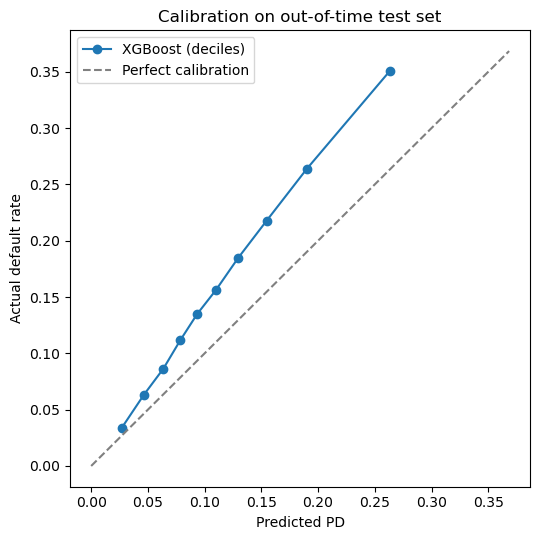

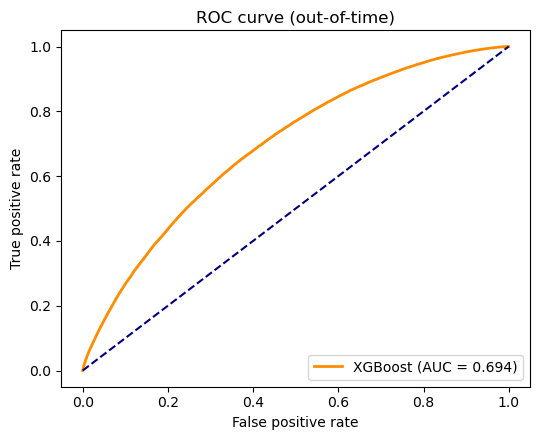

In [16]:
cal = pd.DataFrame({"pd": p_xgb, "y": y_test.values})
cal["decile"] = pd.qcut(cal["pd"], 10, labels=False, duplicates="drop")
cal_tbl = cal.groupby("decile").agg(predicted=("pd", "mean"), actual=("y", "mean"), n=("y", "size"))
print(cal_tbl)

plt.figure(figsize=(5.5, 5.5))
plt.plot(cal_tbl["predicted"], cal_tbl["actual"], "o-", label="XGBoost (deciles)")
lim = max(cal_tbl["predicted"].max(), cal_tbl["actual"].max()) * 1.05
plt.plot([0, lim], [0, lim], "--", color="grey", label="Perfect calibration")
plt.xlabel("Predicted PD"); plt.ylabel("Actual default rate")
plt.title("Calibration on out-of-time test set"); plt.legend(); plt.tight_layout(); plt.show()

fpr, tpr, _ = roc_curve(y_test, p_xgb)
plt.figure(figsize=(5.5, 4.5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot([0, 1], [0, 1], "--", color="navy")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate"); plt.title("ROC curve (out-of-time)")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

In [17]:
# Population Stability Index of the PD distribution: train vs test (monitoring signal).
# Rule of thumb: <0.10 stable, 0.10 to 0.25 moderate shift, >0.25 significant shift.
def psi(expected, actual, bins=10):
    edges = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    e = np.histogram(expected, edges)[0] / len(expected)
    a = np.histogram(actual, edges)[0] / len(actual)
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)
    return float(np.sum((a - e) * np.log(a / e)))

p_train_xgb = xgb.predict_proba(X_train)[:, 1]
print(f"PSI of XGBoost PD (train vs test): {psi(p_train_xgb, p_xgb):.4f}")

PSI of XGBoost PD (train vs test): 0.0465


## 6. Score scaling (PDO) & approval cutoff
Model PDs are rescaled to score points: `Score = Offset + Factor x ln(good:bad odds)`, with `Factor = PDO / ln 2`. 600 points corresponds to the **training-set average odds**, and every 20 points doubles the odds of being good.
This is a **rescaling of model output**, not a points-based scorecard built from binned (WoE) variables. That would be a next step.

In [18]:
factor = PDO / np.log(2)
base_odds = (1 - y_train.mean()) / y_train.mean()
offset = BASE_SCORE - factor * np.log(base_odds)

pd_clip = np.clip(p_xgb, 1e-6, 1 - 1e-6)
score = offset + factor * np.log((1 - pd_clip) / pd_clip)
print(pd.Series(score).describe())

band = pd.DataFrame({"score": score, "y": y_test.values})
band["band"] = pd.qcut(band["score"], 10, duplicates="drop")
print(band.groupby("band", observed=True).agg(avg_score=("score", "mean"), bad_rate=("y", "mean"), n=("y", "size")))

count   423,111.0000
mean        609.5494
std          21.2799
min         538.9323
25%         594.4226
50%         608.2902
75%         622.8479
max         684.9783
dtype: float64
                    avg_score  bad_rate      n
band                                          
(538.931, 582.85]    575.2786    0.3508  42312
(582.85, 591.023]    587.1857    0.2638  42311
(591.023, 597.448]   594.3544    0.2177  42311
(597.448, 603.056]   600.2965    0.1847  42312
(603.056, 608.29]    605.7027    0.1561  42310
(608.29, 613.54]     610.8958    0.1350  42311
(613.54, 619.372]    616.3616    0.1117  42311
(619.372, 627.047]   622.9712    0.0864  42311
(627.047, 639.256]   632.6203    0.0633  42311
(639.256, 684.978]   649.8273    0.0338  42311


In [19]:
# Approval cutoff trade-off: stricter cutoff = fewer approvals, lower bad rate among approved
rows = []
for cutoff in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]:
    approved = p_xgb < cutoff
    rows.append({"PD_cutoff": cutoff, "approval_rate": approved.mean(),
                 "bad_rate_of_approved": y_test.values[approved].mean() if approved.any() else np.nan})
print(pd.DataFrame(rows).to_string(index=False))

 PD_cutoff  approval_rate  bad_rate_of_approved
    0.1000         0.4922                0.0851
    0.1500         0.7352                0.1147
    0.2000         0.8739                0.1347
    0.2500         0.9484                0.1482
    0.3000         0.9823                0.1552
    0.3500         0.9951                0.1586
    0.4000         0.9988                0.1599


## 7. Expected Loss: PD x LGD x EAD, backtested
- **PD:** XGBoost prediction for each test loan (**lifetime** PD over the loan term, not 12-month).
- **LGD:** measured from realised recoveries on **training** defaults (`1 - recoveries / balance outstanding at default`).
- **EAD:** funded amount x the average share of principal still outstanding at default (from training defaults).
- **Backtest:** predicted EL versus actual realised loss on the test loans. A 45% LGD is shown only as an assumed-benchmark comparison.

In [20]:
# Empirical LGD and EAD ratio from TRAIN defaults
d = train[train["target"] == 1]
ead_at_default = d["funded_amnt"] - d["total_rec_prncp"]
lgd_emp = float(np.clip(1 - d["recoveries"].sum() / ead_at_default.sum(), 0, 1))
ead_ratio = float(ead_at_default.sum() / d["funded_amnt"].sum())
print(f"Empirical LGD: {lgd_emp:.2%} | Principal outstanding at default / funded: {ead_ratio:.2%}")

test = test.copy()
test["PD"] = p_xgb
test["EAD"] = test["funded_amnt"]
test["EL_model"] = test["PD"] * lgd_emp * ead_ratio * test["EAD"]
test["EL_45"] = test["PD"] * 0.45 * test["EAD"]
# Realised loss: only defaulted loans lose money; loss = principal not repaid minus recoveries
test["actual_loss"] = (test["target"] * (test["funded_amnt"] - test["total_rec_prncp"] - test["recoveries"])).clip(lower=0)

tot_ead = test["EAD"].sum()
summary = pd.DataFrame({
    "Dollars": [tot_ead, test["EL_model"].sum(), test["EL_45"].sum(), test["actual_loss"].sum()],
    "Pct_of_exposure": [1.0, test["EL_model"].sum() / tot_ead, test["EL_45"].sum() / tot_ead,
                        test["actual_loss"].sum() / tot_ead]},
    index=["Exposure", "Predicted EL (empirical LGD)", "Predicted EL (45% LGD)", "Actual realised loss"])
print(summary.to_string(float_format=lambda x: f"{x:,.4f}" if x < 10 else f"{x:,.0f}"))
print(f"\nPredicted / actual loss (empirical LGD): {test['EL_model'].sum() / test['actual_loss'].sum():.2f}")

Empirical LGD: 87.32% | Principal outstanding at default / funded: 57.56%
                                   Dollars  Pct_of_exposure
Exposure                     5,487,378,325           1.0000
Predicted EL (empirical LGD)   303,865,565           0.0554
Predicted EL (45% LGD)         272,070,189           0.0496
Actual realised loss           456,815,674           0.0832

Predicted / actual loss (empirical LGD): 0.67


In [21]:
# Where does the EL model over- or under-predict? Compare by PD decile.
test["pd_decile"] = pd.qcut(test["PD"], 10, labels=False, duplicates="drop")
by_dec = test.groupby("pd_decile").apply(
    lambda g: pd.Series({"loans": len(g),
                         "pred_loss_rate": g["EL_model"].sum() / g["EAD"].sum(),
                         "actual_loss_rate": g["actual_loss"].sum() / g["EAD"].sum()}),
    include_groups=False)
by_dec["loans"] = by_dec["loans"].astype(int)
print(by_dec.to_string(float_format=lambda x: f"{x:.4f}"))

           loans  pred_loss_rate  actual_loss_rate
pd_decile                                         
0          42312          0.0135            0.0158
1          42311          0.0233            0.0296
2          42311          0.0319            0.0428
3          42311          0.0395            0.0570
4          42311          0.0470            0.0702
5          42311          0.0552            0.0830
6          42311          0.0651            0.0996
7          42311          0.0777            0.1217
8          42311          0.0956            0.1503
9          42311          0.1332            0.2091


In [22]:
# Illustrative stress scenarios. The multipliers are assumptions, not estimates.
scenarios = [("Base", 1.0, lgd_emp),
             ("PD +30%", 1.3, lgd_emp),
             ("PD +30%, LGD +20%", 1.3, min(lgd_emp * 1.2, 1.0))]
stress = []
for name, pd_mult, lgd in scenarios:
    el = ((test["PD"] * pd_mult).clip(upper=1) * lgd * ead_ratio * test["EAD"]).sum()
    stress.append({"Scenario": name, "EL_dollars": el, "EL_pct_of_exposure": el / tot_ead})
print(pd.DataFrame(stress).to_string(index=False, float_format=lambda x: f"{x:,.4f}" if x < 10 else f"{x:,.0f}"))

         Scenario  EL_dollars  EL_pct_of_exposure
             Base 303,865,565              0.0554
          PD +30% 395,025,220              0.0720
PD +30%, LGD +20% 452,389,103              0.0824


## 8. Results, findings & limitations

In [23]:
final = results[["Model", "AUC", "Gini", "KS", "Brier", "Mean_PD", "Actual_default_rate"]].copy()
print("Out-of-time test period:", test["issue_d_dt"].min().date(), "to", test["issue_d_dt"].max().date())
print(final.to_string(index=False))
print(f"\nEmpirical LGD: {lgd_emp:.2%}")
print(f"Predicted EL: {test['EL_model'].sum()/tot_ead:.2%} of exposure | Actual loss: {test['actual_loss'].sum()/tot_ead:.2%}")
print(f"PD PSI (train vs test): {psi(p_train_xgb, p_xgb):.3f}")

Out-of-time test period: 2015-01-01 to 2016-06-01
   Model    AUC   Gini     KS  Brier  Mean_PD  Actual_default_rate
Logistic 0.6908 0.3816 0.2788 0.1282   0.1231               0.1603
 XGBoost 0.6939 0.3879 0.2800 0.1284   0.1157               0.1603

Empirical LGD: 87.32%
Predicted EL: 5.54% of exposure | Actual loss: 8.32%
PD PSI (train vs test): 0.046


### Key findings (write these in your own words after running)
- **Discrimination:** compare logistic vs XGBoost out-of-time. If the gap is small, say that the interpretable model is competitive.
- **Calibration:** do mean predicted PD and actual default rate agree? If not, say why (for example, newer vintages performing differently from the training years).
- **Backtest:** how close is predicted EL to actual loss, and in which PD deciles does it miss?
- **int_rate sensitivity:** how much AUC is lost without it?

### Limitations & next steps
- PD is a **lifetime** PD, not a 12-month PD, so EL is not directly comparable to Basel 12-month or IFRS 9 Stage 1 figures.
- Only 36-month loans are modelled (default). 60-month loans need a longer observation window to avoid censoring.
- The **rejected-applications file is unused**, so there is no reject inference and the model only describes approved borrowers.
- Score scaling only, not a WoE-binned points scorecard.
- LGD and EAD are portfolio averages, not loan-level models. Stress multipliers are illustrative and no macroeconomic variables are used.
- Single out-of-time window and no ongoing monitoring beyond one PSI check.